In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.info())
print(df.isnull().sum())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----

In [2]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove missing customer IDs if customer-level analysis is needed
df = df.dropna(subset=["CustomerID"])

# Remove cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantity and price values
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create sales column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

# Create time-based columns
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Sales  Year  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  15.30  2010   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  2010   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  22.00  2010   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  2010   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  2010   

   Month  Day    Weekday  Hour  
0     12    1  Wednesday     8  
1     12    1  Wednesday     8  
2    

In [5]:
monthly_sales = df.resample("ME", on="InvoiceDate")["Sales"].sum().reset_index()

print(monthly_sales)

   InvoiceDate        Sales
0   2010-12-31   570422.730
1   2011-01-31   568101.310
2   2011-02-28   446084.920
3   2011-03-31   594081.760
4   2011-04-30   468374.331
5   2011-05-31   677355.150
6   2011-06-30   660046.050
7   2011-07-31   598962.901
8   2011-08-31   644051.040
9   2011-09-30   950690.202
10  2011-10-31  1035642.450
11  2011-11-30  1156205.610
12  2011-12-31   517190.440


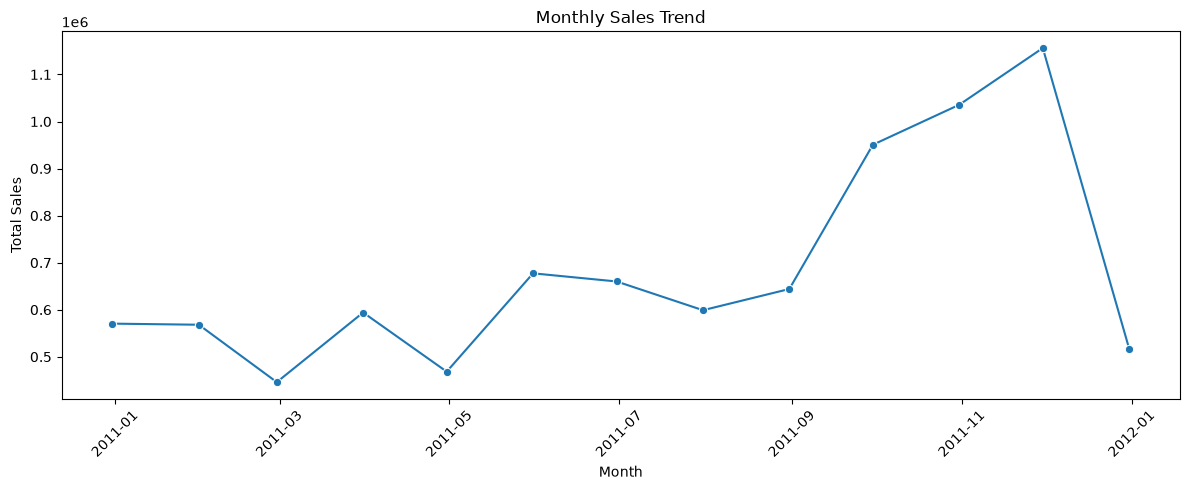

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Sales"] = df["Quantity"] * df["UnitPrice"]

monthly_sales = (
    df.resample("ME", on="InvoiceDate")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="InvoiceDate", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

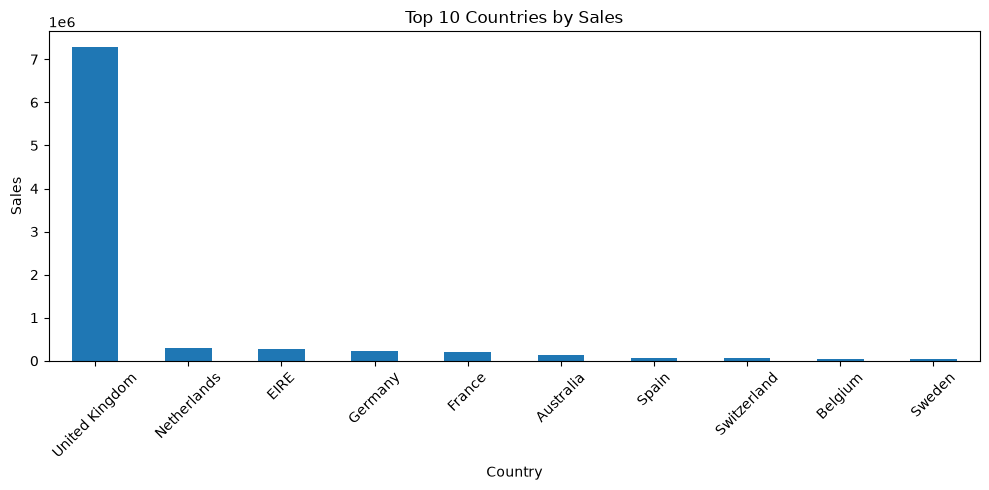

In [7]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

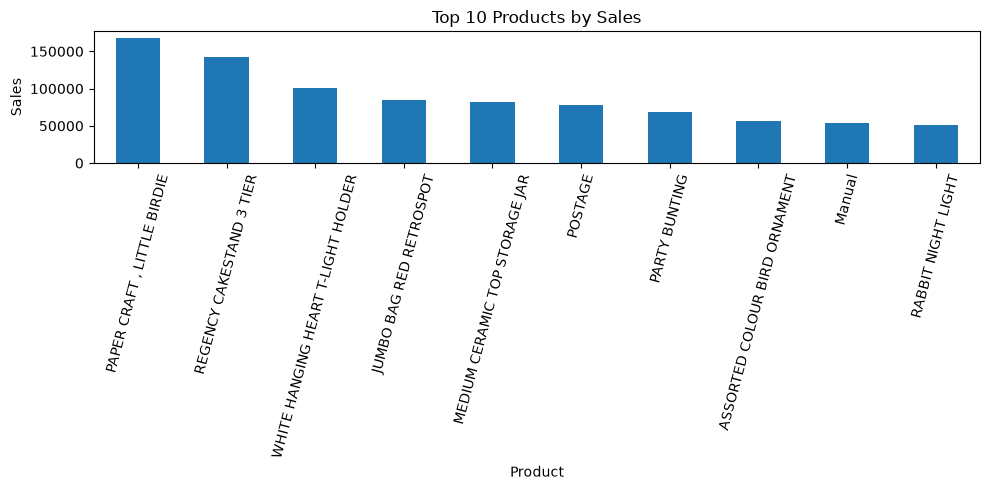

In [8]:
product_sales = df.groupby("Description")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
product_sales.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [9]:
total_sales = df["Sales"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", average_order_value)

Total Sales: 8887208.894000001
Total Orders: 18532
Total Customers: 4338
Average Order Value: 479.56016047917126


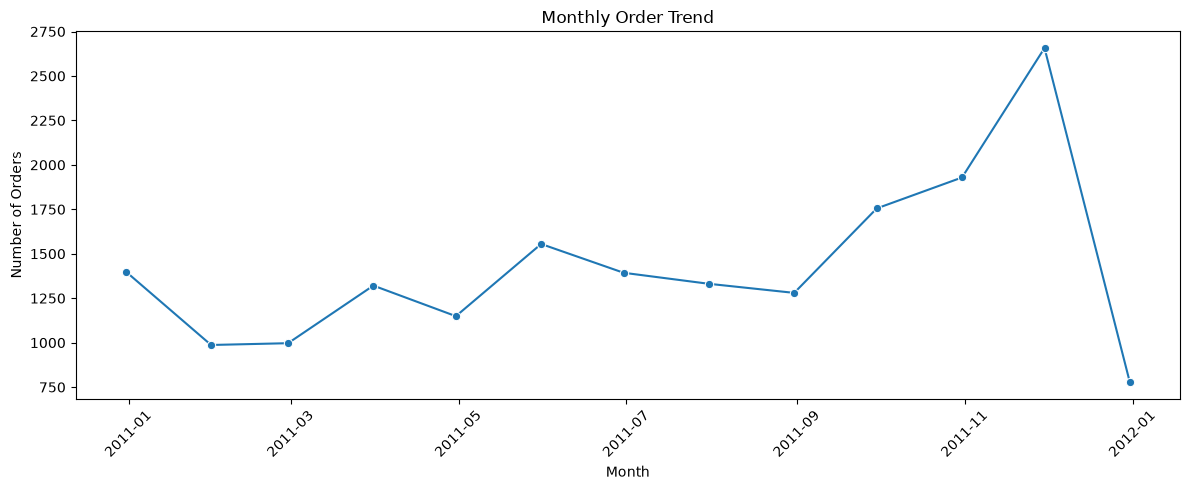

In [11]:
monthly_orders = (
    df.resample("ME", on="InvoiceDate")["InvoiceNo"]
    .nunique()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_orders, x="InvoiceDate", y="InvoiceNo", marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

monthly_sales["Month_Number"] = np.arange(len(monthly_sales))

X = monthly_sales[["Month_Number"]]
y = monthly_sales["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 305686.3848787879
RMSE: 308494.2291611367


In [13]:
future_months = pd.DataFrame({
    "Month_Number": np.arange(len(monthly_sales), len(monthly_sales) + 6)
})

future_predictions = model.predict(future_months)

print(future_predictions)

[ 881848.62177576  912911.16087879  943973.69998182  975036.23908485
 1006098.77818788 1037161.31729091]


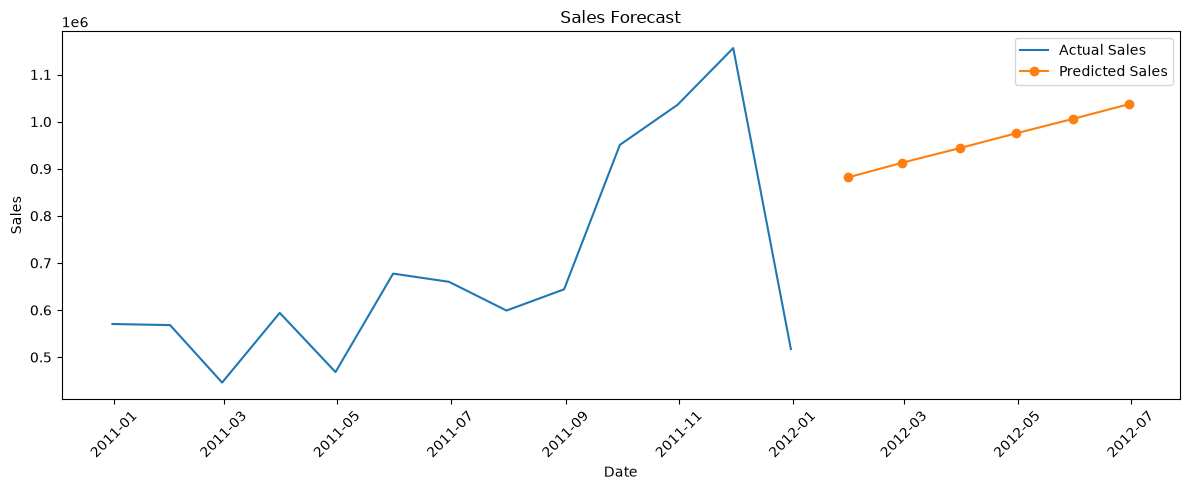

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["InvoiceDate"], monthly_sales["Sales"], label="Actual Sales")

future_dates = pd.date_range(
    start=monthly_sales["InvoiceDate"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="ME"
)

plt.plot(future_dates, future_predictions, marker="o", label="Predicted Sales")

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df = df.drop_duplicates()
df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Sales"] = df["Quantity"] * df["UnitPrice"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Weekday"] = df["InvoiceDate"].dt.day_name()

df.to_csv("cleaned_sales_data.csv", index=False)

print("Cleaned data saved successfully")

Cleaned data saved successfully


In [18]:
df.to_csv("cleaned_sales_data.csv", index=False)